# Retention Recommendation System

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

df          = pd.read_csv('../data/segmented_churn.csv')
final_model = joblib.load('../models/final_model.pkl')
scaler      = joblib.load('../models/scaler.pkl')
scale_cols  = joblib.load('../models/scale_cols.pkl')
threshold   = joblib.load('../models/optimal_threshold.pkl')
feat_names  = joblib.load('../models/feature_names.pkl')

print("Data shape   :", df.shape)
print("Threshold    :", threshold)
print("Segments     :", df['Segment_Label'].value_counts().to_dict())

Data shape   : (7032, 25)
Threshold    : 0.5103298482066214
Segments     : {'Critical Churn-Risk': 2126, 'Stable Mid-Risk': 2029, 'Vulnerable High-Risk': 1744, 'Loyal Low-Risk': 1133}


In [8]:
# Reload original tenure and MonthlyCharges for display only
df_orig = pd.read_csv('../data/cleaned_churn.csv')
df['tenure']         = df_orig['tenure'].values
df['MonthlyCharges'] = df_orig['MonthlyCharges'].values

In [9]:
# Align features to model input
X = df[feat_names].copy()
X[scale_cols] = scaler.transform(X[scale_cols])

df['Churn_Probability'] = final_model.predict_proba(X)[:, 1]
df['Churn_Predicted']   = (df['Churn_Probability'] >= threshold).astype(int)

# Risk tier based on probability
def assign_risk_tier(prob):
    if prob >= 0.75:   return 'Very High'
    elif prob >= 0.51: return 'High'
    elif prob >= 0.30: return 'Medium'
    else:              return 'Low'

df['Risk_Tier'] = df['Churn_Probability'].apply(assign_risk_tier)

print("Risk Tier Distribution:")
print(df['Risk_Tier'].value_counts())
print(f"\nAvg Churn Probability: {df['Churn_Probability'].mean():.3f}")

Risk Tier Distribution:
Risk_Tier
Low          2883
High         1756
Medium       1635
Very High     758
Name: count, dtype: int64

Avg Churn Probability: 0.392


In [10]:
def generate_recommendations(row):
    segment  = row['Segment_Label']
    risk     = row['Risk_Tier']
    prob     = row['Churn_Probability']
    tenure   = row['tenure']
    monthly  = row['MonthlyCharges']
    addons   = row['NumAddons']
    longterm = row['IsLongTermContract']
    fiber    = row['InternetService_Fiber optic']
    security = row['OnlineSecurity']
    support  = row['TechSupport']
    auto_pay = row['IsAutoPayment']

    recommendations = []
    priority        = 'Low'

    # ── CRITICAL CHURN-RISK ──────────────────────────────────────────
    if segment == 'Critical Churn-Risk':
        priority = 'Critical'

        if tenure <= 12:
            recommendations.append(
                "Immediate onboarding call — assign dedicated support agent"
            )
            recommendations.append(
                "Offer 20% discount for first 3 months to reduce early churn"
            )
        else:
            recommendations.append(
                "Personalized retention call — acknowledge loyalty"
            )
            recommendations.append(
                "Offer exclusive loyalty discount: 15% off for 6 months"
            )

        if longterm == 0:
            recommendations.append(
                "Offer contract upgrade incentive: 2 free months on annual plan"
            )

        if fiber == 1 and monthly >= 80:
            recommendations.append(
                "Fiber service review — offer speed upgrade or bill reduction"
            )

        if security == 0 or support == 0:
            recommendations.append(
                "Bundle OnlineSecurity + TechSupport at 50% off for 3 months"
            )

        if auto_pay == 0:
            recommendations.append(
                "Enroll in auto-pay for $5/month discount"
            )

    # ── VULNERABLE HIGH-RISK ─────────────────────────────────────────
    elif segment == 'Vulnerable High-Risk':
        priority = 'High'

        if tenure <= 12:
            recommendations.append(
                "Early engagement: send personalized welcome + value summary email"
            )
            recommendations.append(
                "Offer first add-on service free for 2 months"
            )
        else:
            recommendations.append(
                "Mid-cycle check-in: proactive satisfaction survey + offer"
            )

        if longterm == 0:
            recommendations.append(
                "Promote annual contract: highlight savings vs month-to-month"
            )

        if addons <= 1:
            recommendations.append(
                "Recommend OnlineSecurity or TechSupport — show value demo"
            )

        if monthly <= 50:
            recommendations.append(
                "Upsell opportunity: offer enhanced plan with streaming bundle"
            )

    # ── STABLE MID-RISK ──────────────────────────────────────────────
    elif segment == 'Stable Mid-Risk':
        priority = 'Medium'

        recommendations.append(
            "Send quarterly loyalty reward: bonus data or service credit"
        )

        if addons <= 2:
            recommendations.append(
                "Cross-sell DeviceProtection or StreamingTV at discounted rate"
            )

        if fiber == 1:
            recommendations.append(
                "Proactive fiber quality check — prevent dissatisfaction"
            )

        if auto_pay == 0:
            recommendations.append(
                "Promote auto-pay enrollment for convenience discount"
            )

    # ── LOYAL LOW-RISK ───────────────────────────────────────────────
    elif segment == 'Loyal Low-Risk':
        priority = 'Low'

        recommendations.append(
            "Send annual loyalty thank-you reward: gift card or free month"
        )

        if addons == 0:
            recommendations.append(
                "Introduce premium bundle: StreamingTV + Movies at 30% off"
            )

        recommendations.append(
            "Invite to referral program: reward for bringing new customers"
        )

    return pd.Series({
        'Priority'       : priority,
        'Rec_Count'      : len(recommendations),
        'Recommendations': ' | '.join(recommendations)
    })

# Apply to all customers
print("Generating recommendations...")
rec_df = df.apply(generate_recommendations, axis=1)
df[['Priority', 'Rec_Count', 'Recommendations']] = rec_df

print("Done.")
print(df['Priority'].value_counts())

Generating recommendations...
Done.
Priority
Critical    2126
Medium      2029
High        1744
Low         1133
Name: count, dtype: int64


In [11]:
rec_summary = df.groupby(['Segment_Label', 'Priority']).agg(
    Customers         = ('Churn_Probability', 'count'),
    Avg_Churn_Prob    = ('Churn_Probability', 'mean'),
    Avg_Recommendations = ('Rec_Count', 'mean')
).round(3).reset_index()

print("=== RECOMMENDATION SUMMARY ===")
print(rec_summary.to_string(index=False))

=== RECOMMENDATION SUMMARY ===
       Segment_Label Priority  Customers  Avg_Churn_Prob  Avg_Recommendations
 Critical Churn-Risk Critical       2126           0.690                5.358
      Loyal Low-Risk      Low       1133           0.114                2.898
     Stable Mid-Risk   Medium       2029           0.185                1.880
Vulnerable High-Risk     High       1744           0.452                3.925


In [12]:
print("=" * 70)
for segment in ['Critical Churn-Risk', 'Vulnerable High-Risk',
                'Stable Mid-Risk', 'Loyal Low-Risk']:

    sample = df[df['Segment_Label'] == segment].iloc[0]

    print(f"\nSEGMENT  : {segment}")
    print(f"Priority : {sample['Priority']}")
    print(f"Churn Prob: {sample['Churn_Probability']:.3f}")
    print(f"Tenure   : {sample['tenure']} months")
    print(f"Monthly  : ${sample['MonthlyCharges']:.2f}")
    print("Recommendations:")
    for i, rec in enumerate(sample['Recommendations'].split(' | '), 1):
        print(f"  {i}. {rec}")
    print("-" * 70)


SEGMENT  : Critical Churn-Risk
Priority : Critical
Churn Prob: 0.784
Tenure   : 2 months
Monthly  : $70.70
Recommendations:
  1. Immediate onboarding call — assign dedicated support agent
  2. Offer 20% discount for first 3 months to reduce early churn
  3. Offer contract upgrade incentive: 2 free months on annual plan
  4. Bundle OnlineSecurity + TechSupport at 50% off for 3 months
  5. Enroll in auto-pay for $5/month discount
----------------------------------------------------------------------

SEGMENT  : Vulnerable High-Risk
Priority : High
Churn Prob: 0.645
Tenure   : 1 months
Monthly  : $29.85
Recommendations:
  1. Early engagement: send personalized welcome + value summary email
  2. Offer first add-on service free for 2 months
  3. Promote annual contract: highlight savings vs month-to-month
  4. Recommend OnlineSecurity or TechSupport — show value demo
  5. Upsell opportunity: offer enhanced plan with streaming bundle
---------------------------------------------------------

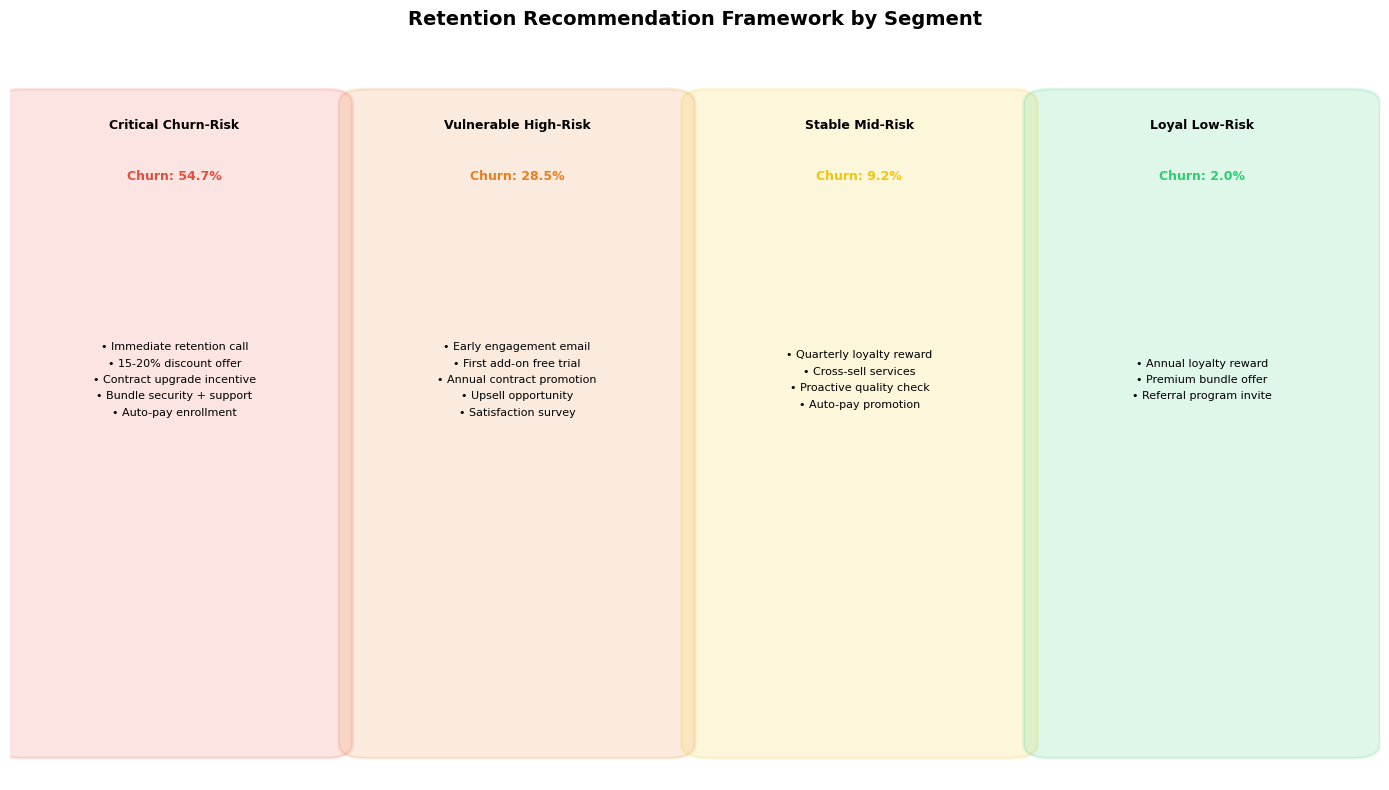

Saved: 25_recommendation_framework.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

segments = [
    ('Critical Churn-Risk',  '54.7%', '#e74c3c',
     '• Immediate retention call\n• 15-20% discount offer\n• Contract upgrade incentive\n• Bundle security + support\n• Auto-pay enrollment'),
    ('Vulnerable High-Risk', '28.5%', '#e67e22',
     '• Early engagement email\n• First add-on free trial\n• Annual contract promotion\n• Upsell opportunity\n• Satisfaction survey'),
    ('Stable Mid-Risk',      '9.2%',  '#f1c40f',
     '• Quarterly loyalty reward\n• Cross-sell services\n• Proactive quality check\n• Auto-pay promotion'),
    ('Loyal Low-Risk',       '2.0%',  '#2ecc71',
     '• Annual loyalty reward\n• Premium bundle offer\n• Referral program invite'),
]

for i, (seg, churn, color, recs) in enumerate(segments):
    x = i * 0.25
    rect = mpatches.FancyBboxPatch(
        (x + 0.01, 0.05), 0.22, 0.88,
        boxstyle='round,pad=0.02',
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=2,
        transform=ax.transAxes
    )
    ax.add_patch(rect)
    ax.text(x + 0.12, 0.90, seg, ha='center', va='center',
            fontsize=9, fontweight='bold', transform=ax.transAxes)
    ax.text(x + 0.12, 0.83, f'Churn: {churn}', ha='center', va='center',
            fontsize=9, color=color, fontweight='bold',
            transform=ax.transAxes)
    ax.text(x + 0.12, 0.55, recs, ha='center', va='center',
            fontsize=8, transform=ax.transAxes,
            linespacing=1.8)

ax.set_title('Retention Recommendation Framework by Segment',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/25_recommendation_framework.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 25_recommendation_framework.png")

In [14]:
# Save full dataset with predictions and recommendations
df.to_csv('../data/final_recommendations.csv', index=False)

# Save recommendation function for deployment
import pickle
with open('../models/recommendation_engine.pkl', 'wb') as f:
    pickle.dump(generate_recommendations, f)

print("Saved:")
print("  data/final_recommendations.csv")
print("  models/recommendation_engine.pkl")

print("\n=== PHASE 10 COMPLETE ===")
print(f"Total customers processed  : {len(df)}")
print(f"Critical priority customers: {(df['Priority']=='Critical').sum()}")
print(f"High priority customers    : {(df['Priority']=='High').sum()}")
print(f"Medium priority customers  : {(df['Priority']=='Medium').sum()}")
print(f"Low priority customers     : {(df['Priority']=='Low').sum()}")
print(f"\nRecommendations saved → data/final_recommendations.csv")

Saved:
  data/final_recommendations.csv
  models/recommendation_engine.pkl

=== PHASE 10 COMPLETE ===
Total customers processed  : 7032
Critical priority customers: 2126
High priority customers    : 1744
Medium priority customers  : 2029
Low priority customers     : 1133

Recommendations saved → data/final_recommendations.csv
